# EEG Lab — Notebook 3: frequency analysis (power spectrum)

**Goal:** measure *how much* of each frequency the signal contains, and show the **eyes-open vs eyes-closed** effect on the alpha rhythm (~10 Hz).

This is the most satisfying moment of the lab: we'll actually *see* the alpha peak appear.

## 1. Prepare the data by condition

We split the signal using the `marker` column (0 = eyes open, 1 = eyes closed) created in Notebook 0.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

df = pd.read_csv('eeg_data.csv')
fs = 250

def band_pass(signal, low, high, fs, order=4):
    nyq = fs/2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

# a back electrode, where alpha is clearest
channel = 'O1'
eyes_open   = band_pass(df.loc[df['marker']==0, channel].to_numpy(), 1, 40, fs)
eyes_closed = band_pass(df.loc[df['marker']==1, channel].to_numpy(), 1, 40, fs)

print("Eyes open  :", len(eyes_open),   "points")
print("Eyes closed:", len(eyes_closed), "points")

Eyes open  : 7500 points
Eyes closed: 7500 points


## 2. Power spectral density (Welch's method)

The `welch` function splits the signal into segments, computes the frequency content of each, and averages them. Result: for each frequency, the **power** (how strongly that frequency is present).

It returns two things: the frequencies `f` and the powers `Pxx`.

In [ ]:
f_open, P_open     = welch(eyes_open,   fs, nperseg=fs*2)
f_closed, P_closed = welch(eyes_closed, fs, nperseg=fs*2)

print("Frequency resolution:", round(f_open[1]-f_open[0], 3), "Hz")

Frequency resolution: 0.5 Hz


## 3. Plot both spectra

We limit the display to 1–40 Hz, the region of interest.

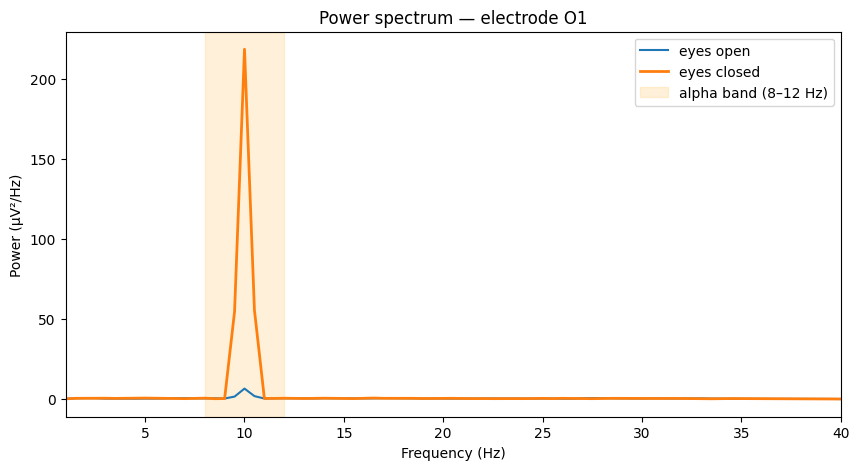

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(f_open, P_open, label='eyes open')
plt.plot(f_closed, P_closed, label='eyes closed', linewidth=2)
plt.axvspan(8, 12, color='orange', alpha=0.15, label='alpha band (8–12 Hz)')
plt.xlim(1, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title(f"Power spectrum — electrode {channel}")
plt.legend()
plt.show()

👀 **Notice** the peak around 10 Hz: it is clearly higher with eyes closed. This is the classic signature of the occipital alpha rhythm.

## 4. Quantify the effect: alpha power

We compute the mean power in the 8–12 Hz band for each condition.

In [ ]:
def alpha_power(f, P):
    band = (f >= 8) & (f <= 12)
    return P[band].mean()

ap_open   = alpha_power(f_open, P_open)
ap_closed = alpha_power(f_closed, P_closed)

print("Alpha power eyes open  :", round(ap_open, 2))
print("Alpha power eyes closed:", round(ap_closed, 2))
print("Ratio closed / open    :", round(ap_closed/ap_open, 1), "times more")

Alpha power eyes open  : 1.49
Alpha power eyes closed: 36.9
Ratio closed / open    : 24.8 times more


## 🧠 Your turn

1. Redo the analysis on **O2**, then on **Fp1** (a frontal electrode). Is the alpha effect as clear at the front of the head?
2. Make a bar chart comparing alpha power open/closed.

*Bar hint: `plt.bar(['open','closed'], [ap_open, ap_closed])`.*

In [ ]:
# Your code here
